# Feasibility Analysis (Conceptual Replication Analysis)

## Data Input

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../df_merge.csv")


In [2]:
df.head()

,Unnamed: 0,id,study_interval,is_weekend,day_in_study,phase,lh,estrogen,pdg,flow_volume,...,calories,steps,is_weekend_exe,averageheartrate,calories_exercise,duration,steps_exercise,Cardio,Sports,Strength
0,0,1,2022,True,1,Follicular,2.9,94.2,NaN,Not at all,...,1542.0,992.0,True,104.0,61.0,1178000.0,651.0,0.0,1.0,0.0
1,1,1,2022,False,2,Follicular,1.2,226.3,NaN,Not at all,...,1591.0,838.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1,2022,False,3,Follicular,3.5,276.8,NaN,Not at all,...,1755.0,2586.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1,2022,False,4,Fertility,1.8,322.1,NaN,Not at all,...,1552.0,1275.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1,2022,False,5,Fertility,4.6,244.9,NaN,Not at all,...,1456.0,436.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df[["id", "study_interval"]].nunique()

id                42
study_interval     2
dtype: int64

In [4]:
for i in df.columns:
    print(i)

Unnamed: 0
id
study_interval
is_weekend
day_in_study
phase
lh
estrogen
pdg
flow_volume
flow_color
appetite
exerciselevel
headaches
cramps
sorebreasts
fatigue
sleepissue
moodswing
stress
foodcravings
indigestion
bloating
glucose_12_2_am
glucose_2_4_am
glucose_4_6_am
glucose_6_8_am
glucose_8_10_am
glucose_10_12_am
glucose_12_2_pm
glucose_2_4_pm
glucose_4_6_pm
glucose_6_8_pm
glucose_8_10_pm
glucose_10_12_pm
glucose_min
glucose_max
glucose_avg
birth_year
gender
ethnicity
education
sexually_active
self_report_menstrual_health_literacy
age_of_first_menarche
height2022
weight2022
height2024
weight2024
study_interval_x
is_weekend_x
timestamp
composition_score
revitalization_score
duration_score
deep_sleep_in_minutes
resting_heart_rate
restlessness
study_interval_y
is_weekend_y
full_sleep_breathing_rate_max
full_sleep_breathing_rate_min
full_sleep_breathing_rate_mean
deep_sleep_breathing_rate_max
deep_sleep_breathing_rate_min
deep_sleep_breathing_rate_mean
light_sleep_breathing_rate_max
light_s

## Data Preprocessing
We only focus on 2022 interval, cope with the reference research, and we add age, BMI, and select some of the columns that might be useful. 

In [5]:
df = df.copy()
df = df[df["study_interval"] == 2022]
df["age"] = df["study_interval"] - df["birth_year"]
df_select = df[["id", "day_in_study", "phase", "resting_heart_rate", 
         "steps", "calories", "minutesasleep",
        "flow_volume", "headaches", "cramps", "sorebreasts", 
         "fatigue", "moodswing", "indigestion", "bloating", "age", "height2022", "weight2022",'nightly_temperature']]


In [6]:
## add BMI

df_select["BMI"] = np.where(
    df_select["weight2022"].notna() & df_select["height2022"].notna(),
    df_select["weight2022"] / ((df_select["height2022"] / 100) ** 2),
    np.nan
)


/var/tmp/ipykernel_5634/3926922311.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select["BMI"] = np.where(


## Survival Analysis (Retention Rate)

### Retention Rate

In [7]:
# Create a "week" variable
df_select["week_in_study"] = (df_select["day_in_study"] / 7).astype(int)

# Count unique participants per week
participants_per_week = (
    df_select.groupby("week_in_study")["id"]
      .nunique()
      .reset_index(name = "n_active"))

# Compute proportion retained relative to week 0
participants_per_week["retention"] = (
    participants_per_week["n_active"] / participants_per_week["n_active"].iloc[0])

print(participants_per_week)


    week_in_study  n_active  retention
0               0        42   1.000000
1               1        42   1.000000
2               2        42   1.000000
3               3        42   1.000000
4               4        42   1.000000
5               5        42   1.000000
6               6        41   0.976190
7               7        41   0.976190
8               8        41   0.976190
9               9        40   0.952381
10             10        40   0.952381
11             11        40   0.952381
12             12        40   0.952381


/var/tmp/ipykernel_5634/3113435101.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select["week_in_study"] = (df_select["day_in_study"] / 7).astype(int)


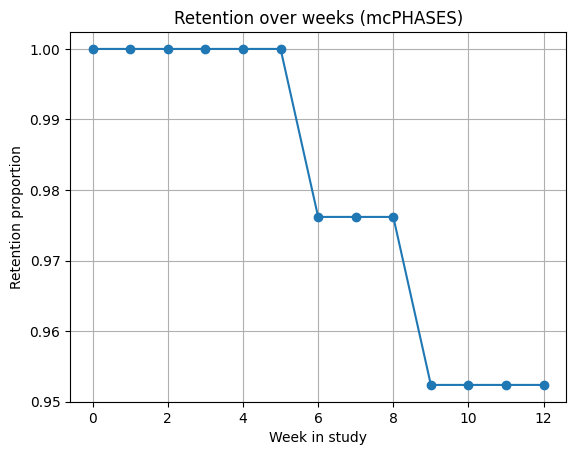

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(participants_per_week["week_in_study"], participants_per_week["retention"], marker="o")
plt.xlabel("Week in study")
plt.ylabel("Retention proportion")
plt.title("Retention over weeks (mcPHASES)")
plt.grid(True)
plt.show()

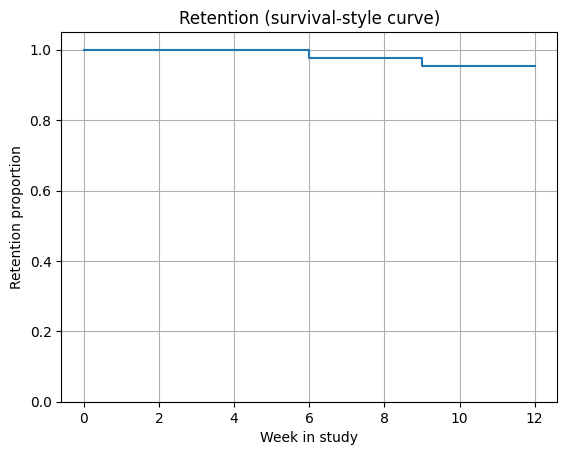

In [9]:
plt.figure()
plt.step(participants_per_week["week_in_study"], participants_per_week["retention"], where="post")
plt.xlabel("Week in study")
plt.ylabel("Retention proportion")
plt.title("Retention (survival-style curve)")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

### Duration for the Study for each ID(Descriptive Statistics)

In [10]:
duration_df = (
    df_select.groupby("id")
      .agg(
          first_day=("day_in_study", "min"),
          last_day=("day_in_study", "max")
      )
      .reset_index()
)

# Compute duration in days
duration_df["duration_days"] = duration_df["last_day"] - duration_df["first_day"]

print(duration_df)

    id  first_day  last_day  duration_days
0    1          1        90             89
1    2          1        90             89
2    3          1        90             89
3    4          1        90             89
4    6          1        90             89
5    7          1        90             89
6    8          1        90             89
7    9          1        90             89
8   10          1        90             89
9   11          1        90             89
10  12          1        90             89
11  13          1        90             89
12  14          1        90             89
13  15          1        90             89
14  16          1        90             89
15  18          1        90             89
16  19          1        90             89
17  20          1        90             89
18  22          1        90             89
19  23          1        90             89
20  24          1        90             89
21  26          1        90             89
22  27     

In [11]:
duration_df['duration_days'].mean()

87.04761904761905

In [12]:
duration_df['duration_days'].std()

9.165024665522091

### FitBit Usage Validibility & Questionnaire Validibility Test

In [13]:
df_select["fitbit_valid"] = df_select[["steps", "resting_heart_rate"]].notna().any(axis=1)

/var/tmp/ipykernel_5634/3606543645.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select["fitbit_valid"] = df_select[["steps", "resting_heart_rate"]].notna().any(axis=1)


In [14]:
questionnaire_cols = ["headaches", "cramps", "moodswing", "fatigue", "bloating"]
df_select["questionnaire_completed"] = df_select[questionnaire_cols].notna().any(axis=1)

/var/tmp/ipykernel_5634/3758435687.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select["questionnaire_completed"] = df_select[questionnaire_cols].notna().any(axis=1)


In [15]:
summary_df = (
    df_select.groupby("id")
      .agg(
          total_days=("day_in_study", "nunique"),
          fitbit_days=("fitbit_valid", "sum"),
          questionnaire_days=("questionnaire_completed", "sum")
      )
      .reset_index()
)

summary_df["pct_fitbit_valid"] = 100 * summary_df["fitbit_days"] / summary_df["total_days"]
summary_df["pct_questionnaire_completed"] = 100 * summary_df["questionnaire_days"] / summary_df["total_days"]

print(summary_df.head())


   id  total_days  fitbit_days  questionnaire_days  pct_fitbit_valid  \
0   1          90           81                  80         90.000000   
1   2          90           90                  89        100.000000   
2   3          90           89                  73         98.888889   
3   4          90           88                  66         97.777778   
4   6          90           89                  77         98.888889   

   pct_questionnaire_completed  
0                    88.888889  
1                    98.888889  
2                    81.111111  
3                    73.333333  
4                    85.555556  


In [16]:
# Calculate overall totals across all rows
total_days = df_select["day_in_study"].count()   # or df.shape[0]
fitbit_valid_days = df_select["fitbit_valid"].sum()
questionnaire_valid_days = df_select["questionnaire_completed"].sum()

overall_fitbit_pct = 100 * fitbit_valid_days / total_days
overall_questionnaire_pct = 100 * questionnaire_valid_days / total_days

print(f"Overall % days with valid Fitbit data: {overall_fitbit_pct:.2f}%")
print(f"Overall % days with completed questionnaires: {overall_questionnaire_pct:.2f}%")


Overall % days with valid Fitbit data: 96.62%
Overall % days with completed questionnaires: 89.78%


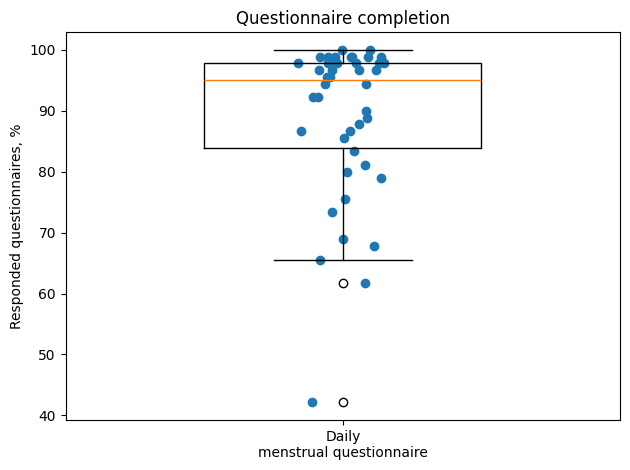

In [17]:
import numpy as np
import matplotlib.pyplot as plt

q_by_id = (
    df_select.groupby("id")["questionnaire_completed"]
             .mean() * 100
)

fig, ax = plt.subplots()

ax.boxplot([q_by_id.values], positions=[1], widths=0.5)

x = np.random.normal(1, 0.04, size=len(q_by_id))
ax.scatter(x, q_by_id.values)

ax.set_xticks([1])
ax.set_xticklabels(["Daily\nmenstrual questionnaire"])
ax.set_ylabel("Responded questionnaires, %")
ax.set_title("Questionnaire completion")

plt.tight_layout()
plt.show()



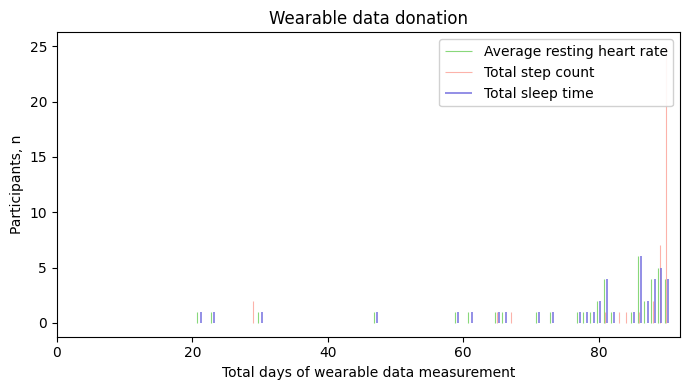

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

by_id_days = (
    df_select.groupby("id")
             .agg(
                 days_RHR   = ("resting_heart_rate", lambda x: x.notna().sum()),
                 days_steps = ("steps",             lambda x: x.notna().sum()),
                 days_sleep = ("minutesasleep",     lambda x: x.notna().sum())
             )
)

cnt_RHR   = by_id_days["days_RHR"].value_counts().sort_index()
cnt_steps = by_id_days["days_steps"].value_counts().sort_index()
cnt_sleep = by_id_days["days_sleep"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))

offset = 0.25

ax.vlines(
    cnt_RHR.index - offset,
    0,
    cnt_RHR.values,
    color="#3BBF21",
    linewidth=0.8,
    alpha=0.6,
    label="Average resting heart rate",
)

ax.vlines(
    cnt_steps.index,
    0,
    cnt_steps.values,
    color="#FA8072",
    linewidth=0.8,
    alpha=0.6,
    label="Total step count",
)

ax.vlines(
    cnt_sleep.index + offset,
    0,
    cnt_sleep.values,
    color="#726DDE",
    linewidth=1.2,
    alpha=0.9,
    label="Total sleep time",
)

ax.set_xlabel("Total days of wearable data measurement")
ax.set_ylabel("Participants, n")
ax.set_title("Wearable data donation")
ax.legend(framealpha=0.9)

xmin = 0
xmax = max(by_id_days.max()) + 2
ax.set_xlim(xmin, xmax)

plt.tight_layout()
plt.show()






In [19]:
(by_id_days["days_sleep"] > 0).sum()

42

In [20]:
df_select['resting_heart_rate'].isnull().sum()

450

In [21]:
df_select.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3698 entries, 0 to 5555
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       3698 non-null   int64  
 1   day_in_study             3698 non-null   int64  
 2   phase                    3697 non-null   object 
 3   resting_heart_rate       3248 non-null   float64
 4   steps                    3573 non-null   float64
 5   calories                 3695 non-null   float64
 6   minutesasleep            3248 non-null   float64
 7   flow_volume              3189 non-null   object 
 8   headaches                3320 non-null   object 
 9   cramps                   3320 non-null   object 
 10  sorebreasts              3320 non-null   object 
 11  fatigue                  3320 non-null   object 
 12  moodswing                3320 non-null   object 
 13  indigestion              3320 non-null   object 
 14  bloating                 3320

### Participants Analysis 

In [22]:
n_participants_ovulatory = df_select.loc[df_select["phase"] == "Fertility", "id"].nunique()
n_participants_ovulatory

42

### Cycle Analysis

In [23]:
import pandas as pd

df_select = df_select.sort_values(["id", "day_in_study"]).reset_index(drop=True)

def assign_cycle(sub):
    sub = sub.copy().reset_index(drop=True)
 
    is_new_cycle = (sub["phase"] == "Menstrual") & (sub["phase"].shift(1) != "Menstrual")
   
    sub["cycle"] = is_new_cycle.cumsum()
    
    return sub

df_select = df_select.groupby("id", group_keys=False).apply(assign_cycle)

df_select = df_select[df_select["cycle"] > 0]



/var/tmp/ipykernel_5634/3594288680.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_select = df_select.groupby("id", group_keys=False).apply(assign_cycle)


In [24]:
df_select["cycle_length"] = (
    df_select.groupby(["id", "cycle"])["day_in_study"]
              .transform("count")
)


In [25]:
df_select.head()

,id,day_in_study,phase,resting_heart_rate,steps,calories,minutesasleep,flow_volume,headaches,cramps,...,age,height2022,weight2022,nightly_temperature,BMI,week_in_study,fitbit_valid,questionnaire_completed,cycle,cycle_length
21,1,22,Menstrual,NaN,2606.0,1757.0,NaN,Not at all,Very Low/Little,Moderate,...,23,NaN,NaN,NaN,NaN,3,True,True,1,30
22,1,23,Menstrual,NaN,434.0,1486.0,NaN,Very Heavy,High,Moderate,...,23,NaN,NaN,NaN,NaN,3,True,True,1,30
23,1,24,Menstrual,80.0,346.0,1595.0,477.0,Somewhat Heavy,Very Low/Little,Very Low/Little,...,23,NaN,NaN,34.901613,NaN,3,True,True,1,30
24,1,25,Menstrual,NaN,1623.0,1461.0,NaN,Moderate,Very Low/Little,Very Low/Little,...,23,NaN,NaN,NaN,NaN,3,True,True,1,30
25,1,26,Menstrual,NaN,561.0,1463.0,NaN,Light,Very Low/Little,Very Low/Little,...,23,NaN,NaN,NaN,NaN,3,True,True,1,30


Remove the cycles that are longer than 35 days to cope with reference paper

In [26]:
cycle_lengths = (
    df_select.groupby(["id", "cycle"])["cycle_length"]
      .first()
      .reset_index()
)

valid_cycles = cycle_lengths[cycle_lengths["cycle_length"] <= 35]


Cycles with at least partical useful data

In [27]:
remaining_cycle_count = valid_cycles.shape[0]
remaining_cycle_count


116

Cycles with complete useful data

In [28]:
keep_pairs = valid_cycles[["id", "cycle"]]

df_filtered = df_select.merge(keep_pairs, on=["id", "cycle"], how="inner")

df_filtered.shape


(2730, 25)

In [29]:
df_select["complete_day"] = (
    df_select["phase"].notna() &
    df_select["resting_heart_rate"].notna() &
    df_select["steps"].notna()
)

In [30]:
cycle_completeness = (
    df_select.groupby(["id", "cycle"])["complete_day"]
      .sum()
      .reset_index(name="n_complete_days")
)


In [31]:
X = 21
valid_cycles = cycle_completeness[cycle_completeness["n_complete_days"] >= X]


In [32]:
N_complete_cycles = valid_cycles.shape[0]
N_complete_cycles


84

### Variable Null values Computation

In [33]:
df_select.columns

Index(['id', 'day_in_study', 'phase', 'resting_heart_rate', 'steps',
       'calories', 'minutesasleep', 'flow_volume', 'headaches', 'cramps',
       'sorebreasts', 'fatigue', 'moodswing', 'indigestion', 'bloating', 'age',
       'height2022', 'weight2022', 'nightly_temperature', 'BMI',
       'week_in_study', 'fitbit_valid', 'questionnaire_completed', 'cycle',
       'cycle_length', 'complete_day'],
      dtype='object')

In [34]:
missing_count = df_select.isna().sum()
missing_count

id                            0
day_in_study                  0
phase                         1
resting_heart_rate          377
steps                       116
calories                      3
minutesasleep               377
flow_volume                 489
headaches                   362
cramps                      362
sorebreasts                 362
fatigue                     362
moodswing                   362
indigestion                 362
bloating                    362
age                           0
height2022                 1574
weight2022                 1339
nightly_temperature         437
BMI                        1721
week_in_study                 0
fitbit_valid                  0
questionnaire_completed       0
cycle                         0
cycle_length                  0
complete_day                  0
dtype: int64

In [35]:
missing_pct = df_select.isna().mean() * 100
missing_pct

id                          0.000000
day_in_study                0.000000
phase                       0.030769
resting_heart_rate         11.600000
steps                       3.569231
calories                    0.092308
minutesasleep              11.600000
flow_volume                15.046154
headaches                  11.138462
cramps                     11.138462
sorebreasts                11.138462
fatigue                    11.138462
moodswing                  11.138462
indigestion                11.138462
bloating                   11.138462
age                         0.000000
height2022                 48.430769
weight2022                 41.200000
nightly_temperature        13.446154
BMI                        52.953846
week_in_study               0.000000
fitbit_valid                0.000000
questionnaire_completed     0.000000
cycle                       0.000000
cycle_length                0.000000
complete_day                0.000000
dtype: float64

In [36]:
missing_summary = pd.DataFrame({
    "missing_count": df_select.isna().sum(),
    "missing_pct": df_select.isna().mean() * 100
}).sort_values("missing_pct", ascending=False)

missing_summary


,missing_count,missing_pct
BMI,1721,52.953846
height2022,1574,48.430769
weight2022,1339,41.200000
flow_volume,489,15.046154
nightly_temperature,437,13.446154
resting_heart_rate,377,11.600000
minutesasleep,377,11.600000
indigestion,362,11.138462
fatigue,362,11.138462
bloating,362,11.138462


In [37]:
# missing_summary.to_csv("missing_summary.csv", index=True)

### Summarize across participants: median [IQR] % completeness.

In [38]:
cols = df_select.columns.drop(["id"])   

completeness_by_id = (
    df_select.groupby("id")[cols]
      .apply(lambda x: x.notna().mean() * 100)
      .reset_index()
)


In [39]:
summary_all = pd.DataFrame({
    "median": completeness_by_id[cols].median(),
    "IQR_low": completeness_by_id[cols].quantile(0.25),
    "IQR_high": completeness_by_id[cols].quantile(0.75),
})

In [40]:
summary_all["formatted"] = summary_all.apply(
    lambda r: f"{r['median']:.1f} [{r['IQR_low']:.1f}, {r['IQR_high']:.1f}]",
    axis=1
)


In [41]:
summary_all

,median,IQR_low,IQR_high,formatted
day_in_study,100.000000,100.000000,100.000000,"100.0 [100.0, 100.0]"
phase,100.000000,100.000000,100.000000,"100.0 [100.0, 100.0]"
resting_heart_rate,94.413919,85.644637,98.373016,"94.4 [85.6, 98.4]"
steps,100.000000,98.494041,100.000000,"100.0 [98.5, 100.0]"
calories,100.000000,100.000000,100.000000,"100.0 [100.0, 100.0]"
minutesasleep,94.413919,85.644637,98.373016,"94.4 [85.6, 98.4]"
flow_volume,88.270911,74.847730,97.371795,"88.3 [74.8, 97.4]"
headaches,94.374110,83.161855,97.495056,"94.4 [83.2, 97.5]"
cramps,94.374110,83.161855,97.495056,"94.4 [83.2, 97.5]"
sorebreasts,94.374110,83.161855,97.495056,"94.4 [83.2, 97.5]"


In [42]:
# summary_all.to_csv("summary_all.csv", index=True)

## Define menstrual phases and align to FEMFIT bins

In [43]:
df_select.groupby("id")["cycle_length"].mean().sort_values()

id
50    20.858824
29    22.233333
15    22.511111
9     24.239437
41    24.352113
18    24.485714
1     25.289855
27    25.314286
37    25.568182
8     25.848485
20    26.066667
44    26.444444
22    26.549296
49    26.578947
42    27.133333
7     27.155556
4     27.333333
26    27.477273
6     27.583333
39    27.641026
3     27.888889
23    28.546667
2     28.859155
38    29.025974
46    29.696629
19    29.702703
24    29.711864
14    30.022222
12    30.155556
10    30.235955
48    30.459459
47    30.955556
45    31.575758
33    31.595238
43    31.698413
34    32.272727
16    32.460317
11    32.906977
32    33.123077
13    38.175000
40    38.558442
30    49.804878
Name: cycle_length, dtype: float64

In [44]:
phase_counts = df_select.groupby("phase").agg(
    subject_days=("id", "count"),
    unique_subjects=("id", "nunique")
)

print(phase_counts)

            subject_days  unique_subjects
phase                                    
Fertility            707               42
Follicular           864               42
Luteal               979               42
Menstrual            699               42


## Recreate Fitbit’s main biological figures


### Cycle-day curves

In [45]:
df_select.columns

Index(['id', 'day_in_study', 'phase', 'resting_heart_rate', 'steps',
       'calories', 'minutesasleep', 'flow_volume', 'headaches', 'cramps',
       'sorebreasts', 'fatigue', 'moodswing', 'indigestion', 'bloating', 'age',
       'height2022', 'weight2022', 'nightly_temperature', 'BMI',
       'week_in_study', 'fitbit_valid', 'questionnaire_completed', 'cycle',
       'cycle_length', 'complete_day'],
      dtype='object')

/var/tmp/ipykernel_5634/1972392348.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("id", group_keys=False).apply(assign_cycle)


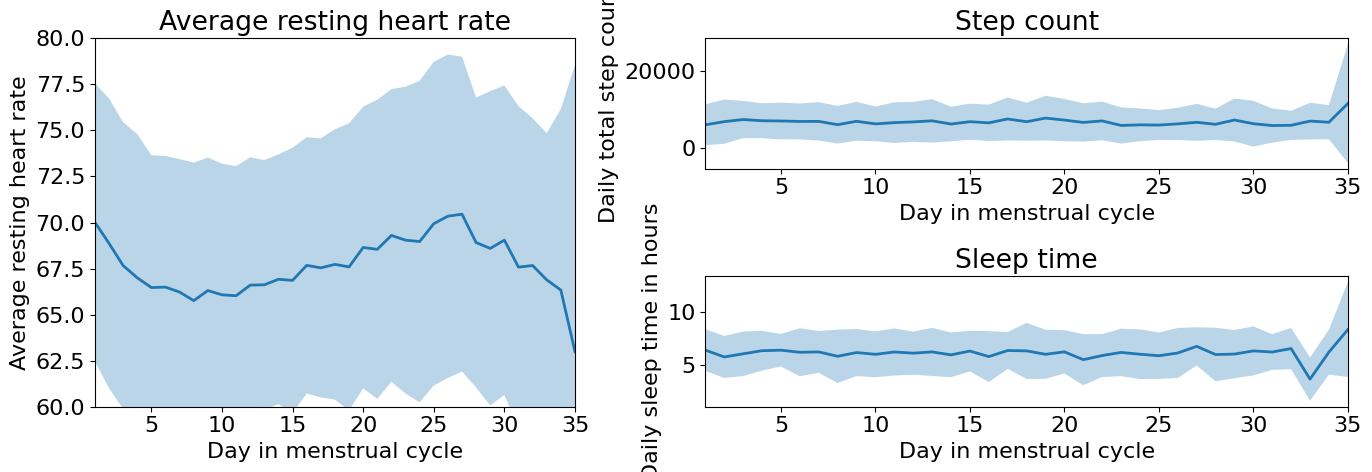

In [46]:
# Phase according to Fitbit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

df = df_select.copy()
df = df.sort_values(["id", "day_in_study"]).reset_index(drop=True)

num_cols = ["resting_heart_rate", "steps", "minutesasleep", "cycle_length"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "fitbit_valid" in df.columns:
    df = df[df["fitbit_valid"] == 1]

if "cycle_length" in df.columns:
    df = df[(df["cycle_length"] >= 21) & (df["cycle_length"] <= 35)]

df["sleep_hours"] = df["minutesasleep"] / 60.0

def assign_cycle(sub):
    sub = sub.copy().reset_index(drop=True)

    is_new_cycle = (sub["phase"] == "Menstrual") & (sub["phase"].shift(1) != "Menstrual")
    sub["cycle"] = is_new_cycle.cumsum()
    return sub

df = df.groupby("id", group_keys=False).apply(assign_cycle)

df = df[df["cycle"] > 0]

df = df.sort_values(["id", "cycle", "day_in_study"])
df["day_in_cycle"] = df.groupby(["id", "cycle"]).cumcount() + 1

if "cycle_length" in df.columns:
    df = df[df["day_in_cycle"] <= df["cycle_length"]]
df = df[df["day_in_cycle"] <= 35]

agg = (
    df.groupby("day_in_cycle")
      .agg(
          rhr_mean=("resting_heart_rate", "mean"),
          rhr_std=("resting_heart_rate", "std"),
          steps_mean=("steps", "mean"),
          steps_std=("steps", "std"),
          sleep_mean=("sleep_hours", "mean"),
          sleep_std=("sleep_hours", "std"),
      )
      .reset_index()
      .sort_values("day_in_cycle")
)

for col in ["rhr_std", "steps_std", "sleep_std"]:
    agg[col] = agg[col].fillna(0)

x = agg["day_in_cycle"].values

plt.rcParams["font.size"] = 16

fig = plt.figure(figsize=(14, 5))
gs = GridSpec(2, 3, figure=fig, width_ratios=[3, 1.6, 1.6])

ax1 = fig.add_subplot(gs[:, 0])
ax1.fill_between(x,
                 agg["rhr_mean"] - agg["rhr_std"],
                 agg["rhr_mean"] + agg["rhr_std"],
                 alpha=0.3)
ax1.plot(x, agg["rhr_mean"], linewidth=2)
ax1.set_title("Average resting heart rate")
ax1.set_xlabel("Day in menstrual cycle")
ax1.set_ylabel("Average resting heart rate")
ax1.set_xlim(1, 35)
ax1.set_ylim(60, 80)   

ax2 = fig.add_subplot(gs[0, 1:])
ax2.fill_between(x,
                 agg["steps_mean"] - agg["steps_std"],
                 agg["steps_mean"] + agg["steps_std"],
                 alpha=0.3)
ax2.plot(x, agg["steps_mean"], linewidth=2)
ax2.set_title("Step count")
ax2.set_xlabel("Day in menstrual cycle")
ax2.set_ylabel("Daily total step count")
ax2.set_xlim(1, 35)

ax3 = fig.add_subplot(gs[1, 1:])
ax3.fill_between(x,
                 agg["sleep_mean"] - agg["sleep_std"],
                 agg["sleep_mean"] + agg["sleep_std"],
                 alpha=0.3)
ax3.plot(x, agg["sleep_mean"], linewidth=2)
ax3.set_title("Sleep time")
ax3.set_xlabel("Day in menstrual cycle")
ax3.set_ylabel("Daily sleep time in hours")
ax3.set_xlim(1, 35)

plt.tight_layout()
plt.show()




In [47]:
# Phase according to the paper's calculation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

df = df_select.copy()
df = df.sort_values(["id", "day_in_study"]).reset_index(drop=True)

num_cols = ["resting_heart_rate", "steps", "minutesasleep", "cycle_length"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "fitbit_valid" in df.columns:
    df = df[df["fitbit_valid"] == 1]

df = df[(df["cycle_length"] >= 21) & (df["cycle_length"] <= 35)]

df["sleep_hours"] = df["minutesasleep"] / 60.0

def assign_cycle(sub):
    sub = sub.copy().reset_index(drop=True)
    is_new_cycle = (sub["phase"] == "Menstrual") & (sub["phase"].shift(1) != "Menstrual")
    sub["cycle"] = is_new_cycle.cumsum()
    return sub

df = df.groupby("id", group_keys=False).apply(assign_cycle)
df = df[df["cycle"] > 0]  

df = df.sort_values(["id", "cycle", "day_in_study"])
df["day_in_cycle"] = df.groupby(["id", "cycle"]).cumcount() + 1

df = df[df["day_in_cycle"] <= df["cycle_length"]]
df = df[df["day_in_cycle"] <= 35]

df["ovulation_day"] = df["cycle_length"] - 14

df["is_luteal"] = df["day_in_cycle"] > df["ovulation_day"]
df["is_menses"] = df["day_in_cycle"].between(1, 5)


/var/tmp/ipykernel_5634/3764355142.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("id", group_keys=False).apply(assign_cycle)


In [48]:
agg = (
    df.groupby("day_in_cycle")
      .agg(
          rhr_mean=("resting_heart_rate", "mean"),
          rhr_std=("resting_heart_rate", "std"),
          steps_mean=("steps", "mean"),
          steps_std=("steps", "std"),
          sleep_mean=("sleep_hours", "mean"),
          sleep_std=("sleep_hours", "std")
      )
      .reset_index()
      .sort_values("day_in_cycle")
)

for col in ["rhr_std", "steps_std", "sleep_std"]:
    agg[col] = agg[col].fillna(0)

x = agg["day_in_cycle"].values


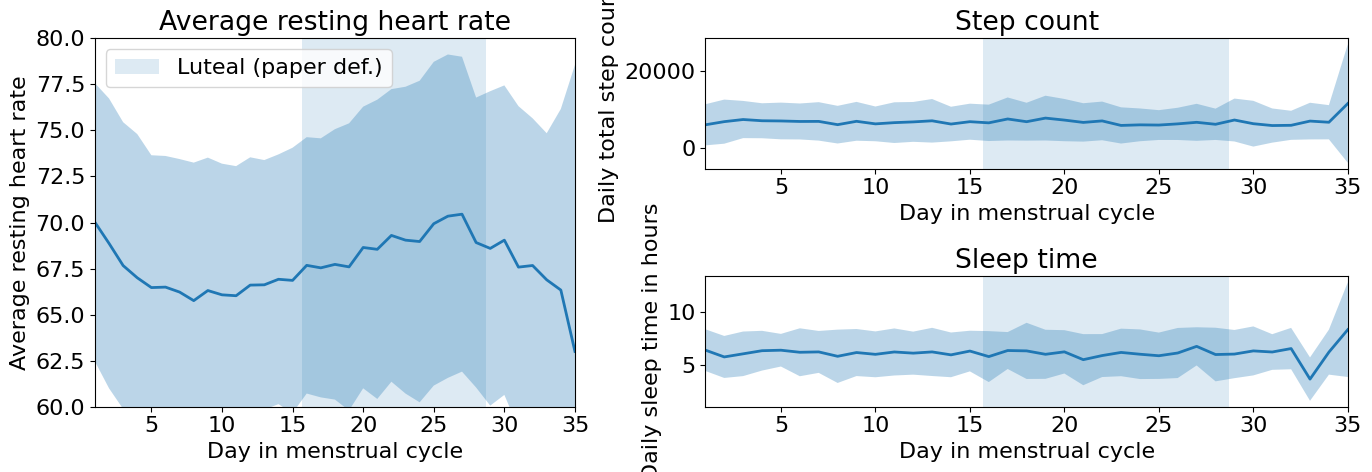

In [49]:
mean_cycle_len = df["cycle_length"].mean()
mean_ovu_day = mean_cycle_len - 14
luteal_start = mean_ovu_day + 1
luteal_end = min(35, mean_cycle_len)

plt.rcParams["font.size"] = 16
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(2, 3, figure=fig, width_ratios=[3, 1.6, 1.6])

ax1 = fig.add_subplot(gs[:, 0])

ax1.axvspan(luteal_start, luteal_end, alpha=0.15, label="Luteal (paper def.)")

ax1.fill_between(x,
                 agg["rhr_mean"] - agg["rhr_std"],
                 agg["rhr_mean"] + agg["rhr_std"],
                 alpha=0.3)
ax1.plot(x, agg["rhr_mean"], linewidth=2)
ax1.set_title("Average resting heart rate")
ax1.set_xlabel("Day in menstrual cycle")
ax1.set_ylabel("Average resting heart rate")
ax1.set_xlim(1, 35)
ax1.set_ylim(60, 80)
ax1.legend(loc="upper left")

ax2 = fig.add_subplot(gs[0, 1:])
ax2.axvspan(luteal_start, luteal_end, alpha=0.15)
ax2.fill_between(x,
                 agg["steps_mean"] - agg["steps_std"],
                 agg["steps_mean"] + agg["steps_std"],
                 alpha=0.3)
ax2.plot(x, agg["steps_mean"], linewidth=2)
ax2.set_title("Step count")
ax2.set_xlabel("Day in menstrual cycle")
ax2.set_ylabel("Daily total step count")
ax2.set_xlim(1, 35)

ax3 = fig.add_subplot(gs[1, 1:])
ax3.axvspan(luteal_start, luteal_end, alpha=0.15)
ax3.fill_between(x,
                 agg["sleep_mean"] - agg["sleep_std"],
                 agg["sleep_mean"] + agg["sleep_std"],
                 alpha=0.3)
ax3.plot(x, agg["sleep_mean"], linewidth=2)
ax3.set_title("Sleep time")
ax3.set_xlabel("Day in menstrual cycle")
ax3.set_ylabel("Daily sleep time in hours")
ax3.set_xlim(1, 35)

plt.tight_layout()
plt.show()


In [50]:
# phase according to label we have
phase_means_own = (
    df.groupby(['id', 'phase'])[['resting_heart_rate', 'steps', 'sleep_hours']]
      .mean()
      .reset_index()
)
phase_means_own


,id,phase,resting_heart_rate,steps,sleep_hours
0,1,Fertility,75.000000,3979.272727,5.802778
1,1,Follicular,77.500000,1913.714286,6.200000
2,1,Luteal,76.545455,3301.541667,5.157576
3,1,Menstrual,78.666667,2178.181818,5.777778
4,2,Fertility,61.142857,6692.642857,7.307143
...,...,...,...,...,...
155,49,Menstrual,74.000000,5130.000000,7.770833
156,50,Fertility,62.263158,11916.619048,5.071053
157,50,Follicular,62.000000,12598.250000,4.982609
158,50,Luteal,60.636364,9214.181818,5.248485


### RHR

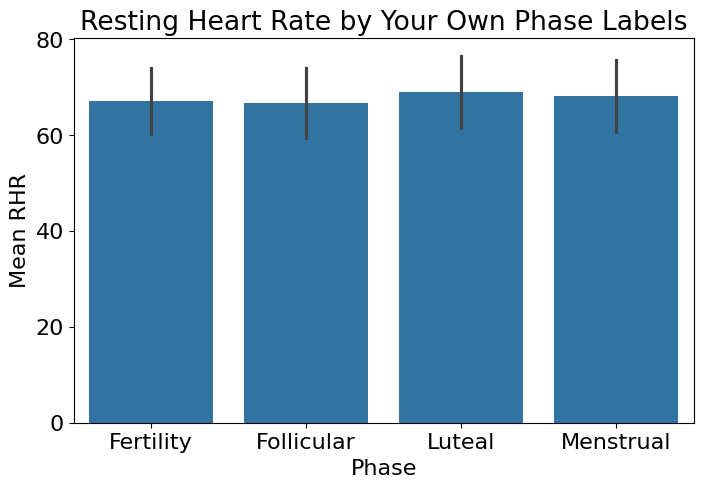

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=phase_means_own,
    x='phase',
    y='resting_heart_rate',
    errorbar='sd'
)
plt.title('Resting Heart Rate by Your Own Phase Labels')
plt.xlabel('Phase')
plt.ylabel('Mean RHR')
plt.show()


In [52]:
import statsmodels.formula.api as smf

model_own = smf.mixedlm(
    "resting_heart_rate ~ C(phase)",
    data=phase_means_own,
    groups=phase_means_own["id"]
).fit()

print(model_own.summary())


              Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: resting_heart_rate
No. Observations:  160     Method:             REML              
No. Groups:        40      Scale:              2.9411            
Min. group size:   4       Log-Likelihood:     -395.4669         
Max. group size:   4       Converged:          Yes               
Mean group size:   4.0                                           
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              67.059    1.151 58.254 0.000 64.803 69.315
C(phase)[T.Follicular] -0.413    0.383 -1.078 0.281 -1.165  0.338
C(phase)[T.Luteal]      1.924    0.383  5.018 0.000  1.173  2.676
C(phase)[T.Menstrual]   1.000    0.383  2.607 0.009  0.248  1.751
Group Var              50.064    7.746                           



In [53]:
# Phase according to paper's rule

df['ovulation_day'] = df['cycle_length'] - 14

df['phase_paper'] = 'Follicular'

df.loc[df['day_in_cycle'].between(1,5), 'phase_paper'] = 'Menses'
df.loc[df['day_in_cycle'] == df['ovulation_day'], 'phase_paper'] = 'Ovulation'

df.loc[
    df['day_in_cycle'].between(df['ovulation_day']+3, df['ovulation_day']+9),
    'phase_paper'
] = 'MidLuteal'

df.loc[
    df['day_in_cycle'] > df['ovulation_day']+9,
    'phase_paper'
] = 'LateLuteal'


In [54]:
df['phase_paper'] = df['phase_paper'].replace({
    'MidLuteal': 'Luteal',
    'LateLuteal': 'Luteal',
})


phase_means = (
    df.groupby(['id', 'phase_paper'])[['resting_heart_rate','steps','sleep_hours']]
      .mean()
      .reset_index()
)


In [55]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "resting_heart_rate ~ C(phase_paper)",
    data=phase_means,
    groups=phase_means["id"]
).fit()

print(model.summary())


                Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   resting_heart_rate
No. Observations:   160       Method:               REML              
No. Groups:         40        Scale:                2.3352            
Min. group size:    4         Log-Likelihood:       -382.1672         
Max. group size:    4         Converged:            Yes               
Mean group size:    4.0                                               
----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                   66.720    1.152 57.928 0.000 64.463 68.978
C(phase_paper)[T.Luteal]     1.923    0.342  5.628 0.000  1.253  2.593
C(phase_paper)[T.Menses]     1.380    0.342  4.039 0.000  0.711  2.050
C(phase_paper)[T.Ovulation]  0.150    0.342  0.440 0.660 -0.519  0.820
Group Var              

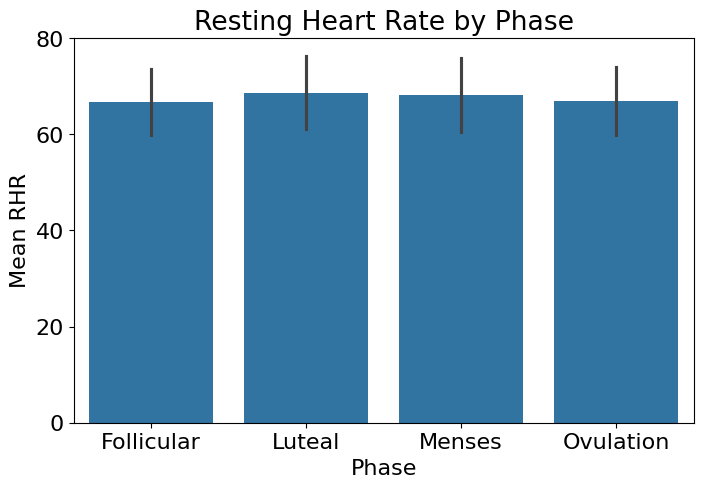

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=phase_means,
    x='phase_paper',
    y='resting_heart_rate',
    errorbar='sd'
)
plt.title('Resting Heart Rate by Phase')
plt.xlabel('Phase')
plt.ylabel('Mean RHR')
plt.show()


In [57]:
df_select = df_select.copy()

df_select = df_select.sort_values(["id", "cycle", "day_in_study"])

df_select["day_in_cycle"] = (
    df_select.groupby(["id", "cycle"])
             .cumcount() + 1
)


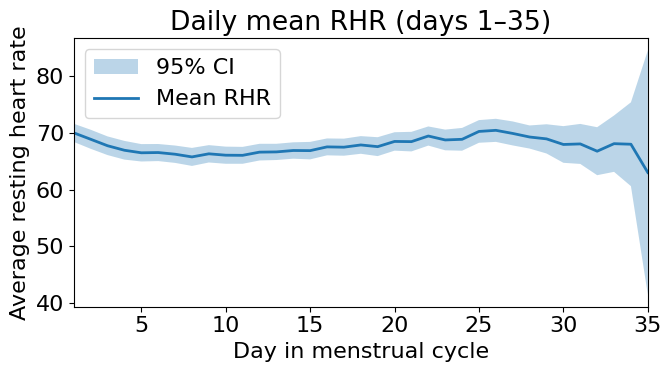

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_use = df_select.copy()
df_use = df_use[(df_use['cycle_length'] >= 21) & (df_use['cycle_length'] <= 35)]
df_use = df_use[df_use['day_in_cycle'] <= 35]

daily = (
    df_use.groupby('day_in_cycle')
          .agg(
              mean_rhr=('resting_heart_rate', 'mean'),
              sem_rhr=('resting_heart_rate', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
              n=('id', 'nunique')
          )
          .reset_index()
          .sort_values('day_in_cycle')
)

daily['ci_low'] = daily['mean_rhr'] - 1.96 * daily['sem_rhr']
daily['ci_high'] = daily['mean_rhr'] + 1.96 * daily['sem_rhr']

x = daily['day_in_cycle'].values

plt.figure(figsize=(7,4))
plt.fill_between(x, daily['ci_low'], daily['ci_high'], alpha=0.3, label='95% CI')
plt.plot(x, daily['mean_rhr'], linewidth=2, label='Mean RHR')
plt.xlabel('Day in menstrual cycle')
plt.ylabel('Average resting heart rate')
plt.title('Daily mean RHR (days 1–35)')
plt.xlim(1, 35)
plt.legend()
plt.tight_layout()
plt.show()


In [59]:
df_phase = df_use.copy()

# ovulation day
df_phase['ovulation_day'] = df_phase['cycle_length'] - 14

df_phase['phase_paper'] = 'Follicular'

df_phase.loc[df_phase['day_in_cycle'].between(1,5), 'phase_paper'] = 'Menses'

# Mid-luteal: ovulation+3 ~ ovulation+9
df_phase.loc[
    df_phase['day_in_cycle'].between(
        df_phase['ovulation_day'] + 3,
        df_phase['ovulation_day'] + 9
    ),
    'phase_paper'
] = 'MidLuteal'

# Late-luteal: ovulation+10 ~ cycle_length
df_phase.loc[
    df_phase['day_in_cycle'] > (df_phase['ovulation_day'] + 9),
    'phase_paper'
] = 'LateLuteal'


In [60]:
ph_keep = ['Menses', 'MidLuteal', 'LateLuteal']
df_phase = df_phase[df_phase['phase_paper'].isin(ph_keep)]


In [61]:
phase_means = (
    df_phase.groupby(['id', 'phase_paper'])['resting_heart_rate']
            .mean()
            .reset_index()
)


In [62]:
pm = phase_means.pivot(index='id', columns='phase_paper', values='resting_heart_rate')
pm = pm[['Menses', 'MidLuteal', 'LateLuteal']].dropna()
pm.head()


phase_paper,Menses,MidLuteal,LateLuteal
id,,,
1,78.666667,75.666667,77.666667
2,60.800000,61.785714,62.900000
3,63.642857,63.333333,63.933333
4,74.714286,73.388889,76.333333
6,51.400000,53.200000,54.250000


In [63]:
from scipy import stats
import numpy as np

mid_diff  = pm['MidLuteal']  - pm['Menses']
late_diff = pm['LateLuteal'] - pm['Menses']

w_mid,  p_mid  = stats.wilcoxon(pm['MidLuteal'], pm['Menses'])
w_late, p_late = stats.wilcoxon(pm['LateLuteal'], pm['Menses'])

print("MidLuteal vs Menses:  p =", p_mid)
print("LateLuteal vs Menses: p =", p_late)

def cohens_d_z(diff):
    return diff.mean() / diff.std(ddof=1)

d_mid  = cohens_d_z(mid_diff)
d_late = cohens_d_z(late_diff)

print("Effect size dz (MidLuteal - Menses): ", d_mid)
print("Effect size dz (LateLuteal - Menses):", d_late)


MidLuteal vs Menses:  p = 0.7954479165618977
LateLuteal vs Menses: p = 0.0011977062064495603
Effect size dz (MidLuteal - Menses):  -0.03306976122971508
Effect size dz (LateLuteal - Menses): 0.5175192001930177


In [64]:
orig_effect_bpm_mid  = 2.0   
orig_effect_bpm_late = 2.5   


In [65]:
# luteal > menses?
direction_mid_ok  = mid_diff.mean()  > 0
direction_late_ok = late_diff.mean() > 0

# whether reaches half of the original
rep_effect_mid_bpm  = mid_diff.mean()
rep_effect_late_bpm = late_diff.mean()

size_mid_ok  = rep_effect_mid_bpm  >= 0.5 * orig_effect_bpm_mid
size_late_ok = rep_effect_late_bpm >= 0.5 * orig_effect_bpm_late

# Significance
alpha = 0.05
sig_mid_ok  = p_mid  < alpha
sig_late_ok = p_late < alpha

print("Mid-luteal conceptual replication?",
      direction_mid_ok and size_mid_ok and sig_mid_ok)

print("Late-luteal conceptual replication?",
      direction_late_ok and size_late_ok and sig_late_ok)


Mid-luteal conceptual replication? False
Late-luteal conceptual replication? True


### Steps

In [66]:
from scipy.stats import mannwhitneyu

df = df_select.copy()

sym_cols = ['headaches','cramps','sorebreasts','fatigue',
            'moodswing','indigestion','bloating']

severity_map = {
    "Not at all": 0,
    "Very Low/Little": 1,
    "Low": 1,
    "Moderate": 2,
    "High": 3,
    "Very High": 3
}

for c in sym_cols:
    df[c] = pd.to_numeric(df[c], errors='ignore').replace(severity_map)
    df[c] = df[c].astype(float)

df['PMS_score'] = df[sym_cols].mean(axis=1)

pms_by_id = df.groupby('id')['PMS_score'].mean()


pms_group = np.where(pms_by_id >= 1.5, 'Severe', 'Low')
pms_group = pd.Series(pms_group, index=pms_by_id.index, name='PMS_group')

df = df.merge(pms_group, on='id')

target = df[df["phase"].isin(["Luteal", "Menstrual"])]

avg_steps = target.groupby(['id', 'PMS_group'])['steps'].mean().reset_index()

sev = avg_steps[avg_steps["PMS_group"]=="Severe"]["steps"]
low = avg_steps[avg_steps["PMS_group"]=="Low"]["steps"]

u, p = mannwhitneyu(sev, low, alternative="two-sided")

n1, n2 = len(sev), len(low)
z = (u - (n1*n2)/2) / np.sqrt(n1*n2*(n1+n2+1)/12)
r = abs(z) / np.sqrt(n1+n2)

print("===== Steps: Severe PMS vs Low PMS =====")
print(f"Severe PMS: mean {sev.mean():.0f} ± {sev.std():.0f} steps")
print(f"Low PMS   : mean {low.mean():.0f} ± {low.std():.0f} steps")
print()
print(f"Mann–Whitney U = {u:.1f}, p = {p:.4g}")
print(f"Effect size r = {r:.3f}")

===== Steps: Severe PMS vs Low PMS =====
Severe PMS: mean 7891 ± 2292 steps
Low PMS   : mean 6339 ± 2641 steps

Mann–Whitney U = 169.0, p = 0.1223
Effect size r = 0.242


/var/tmp/ipykernel_5634/2150102398.py:18: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore').replace(severity_map)
/var/tmp/ipykernel_5634/2150102398.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[c] = pd.to_numeric(df[c], errors='ignore').replace(severity_map)
/var/tmp/ipykernel_5634/2150102398.py:18: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore').replace(severity_map)
/var/tmp/ipykernel_5634/2150102398.py:18: FutureWarning: Downcasti

### Sleep Duration

In [67]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

df = df_select.copy()

sym_cols = ['headaches','cramps','sorebreasts','fatigue',
            'moodswing','indigestion','bloating']

severity_map = {
    "Not at all": 0,
    "Very Low/Little": 1,
    "Low": 1,
    "Moderate": 2,
    "High": 3,
    "Very High": 3
}

for c in sym_cols:
    df[c] = pd.to_numeric(df[c], errors='ignore').replace(severity_map).astype(float)

df['PMS_score'] = df[sym_cols].mean(axis=1)

# ID-level PMS score
pms_by_id = df.groupby('id')['PMS_score'].mean()

pms_group = np.where(pms_by_id >= 1.5, 'Severe', 'Low')
pms_group = pd.Series(pms_group, index=pms_by_id.index, name='PMS_group')

df = df.merge(pms_group, on='id')

target = df[df["phase"].isin(["Luteal", "Menstrual"])]

target["sleep_hours"] = pd.to_numeric(target["minutesasleep"], errors='coerce') / 60

avg_sleep = target.groupby(['id', 'PMS_group'])['sleep_hours'].mean().reset_index()

sev = avg_sleep[avg_sleep["PMS_group"]=="Severe"]["sleep_hours"]
low = avg_sleep[avg_sleep["PMS_group"]=="Low"]["sleep_hours"]

u, p = mannwhitneyu(sev, low, alternative="two-sided")

# effect size r
n1, n2 = len(sev), len(low)
z = (u - (n1*n2)/2) / np.sqrt(n1*n2*(n1+n2+1)/12)
r = abs(z) / np.sqrt(n1+n2)

print("===== Sleep: Severe PMS vs Low PMS =====")
print(f"Severe PMS: {sev.mean():.2f} ± {sev.std():.2f} hours")
print(f"Low PMS   : {low.mean():.2f} ± {low.std():.2f} hours")
print()
print(f"Mann–Whitney U = {u:.1f}, p = {p:.4g}")
print(f"Effect size r = {r:.3f}")


===== Sleep: Severe PMS vs Low PMS =====
Severe PMS: 5.69 ± 0.91 hours
Low PMS   : 6.23 ± 0.89 hours

Mann–Whitney U = 91.0, p = 0.3026
Effect size r = 0.164


/var/tmp/ipykernel_5634/1431668906.py:20: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore').replace(severity_map).astype(float)
/var/tmp/ipykernel_5634/1431668906.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[c] = pd.to_numeric(df[c], errors='ignore').replace(severity_map).astype(float)
/var/tmp/ipykernel_5634/1431668906.py:20: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore').replace(severity_map).astype(float)
/var/tmp/ipykernel_5634/

### PMS

In [68]:
df_select.columns

Index(['id', 'day_in_study', 'phase', 'resting_heart_rate', 'steps',
       'calories', 'minutesasleep', 'flow_volume', 'headaches', 'cramps',
       'sorebreasts', 'fatigue', 'moodswing', 'indigestion', 'bloating', 'age',
       'height2022', 'weight2022', 'nightly_temperature', 'BMI',
       'week_in_study', 'fitbit_valid', 'questionnaire_completed', 'cycle',
       'cycle_length', 'complete_day', 'day_in_cycle'],
      dtype='object')

In [69]:
df_select['phase'].value_counts()

phase
Luteal        979
Follicular    864
Fertility     707
Menstrual     699
Name: count, dtype: int64

In [70]:
df_select['headaches'].value_counts()

headaches
Not at all         945
Very Low/Little    752
Moderate           453
Low                448
High               222
Very High           68
Name: count, dtype: int64

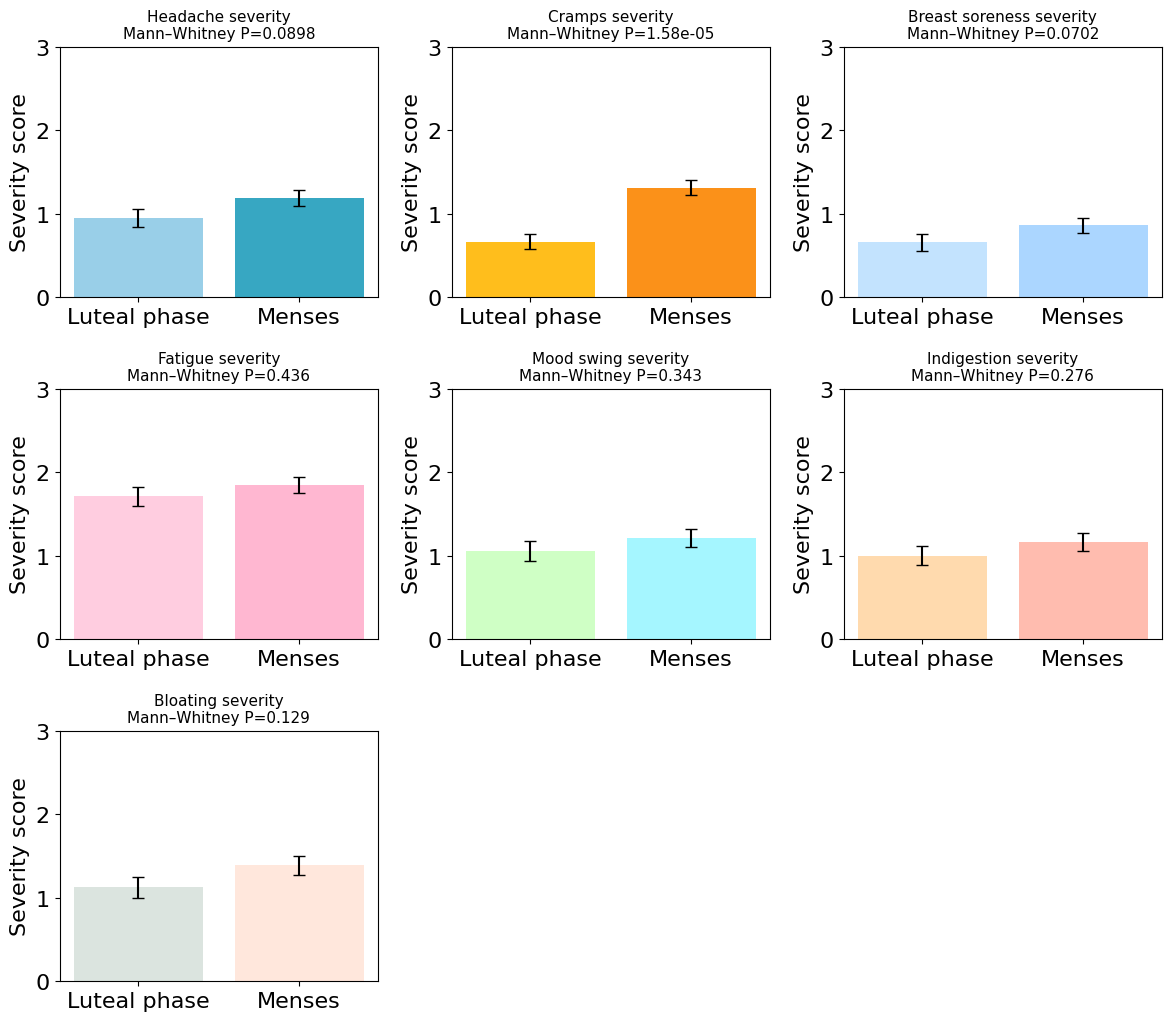

Mann–Whitney tests (Luteal vs Menses):
Headache severity      U=692.0, p=0.08976, mean_L=0.949, mean_M=1.191, n=42
Cramps severity        U=399.5, p=1.579e-05, mean_L=0.664, mean_M=1.311, n=42
Breast soreness severity U=680.0, p=0.07021, mean_L=0.658, mean_M=0.862, n=42
Fatigue severity       U=794.5, p=0.4362, mean_L=1.710, mean_M=1.851, n=42
Mood swing severity    U=775.5, p=0.3425, mean_L=1.062, mean_M=1.212, n=42
Indigestion severity   U=760.0, p=0.2765, mean_L=1.002, mean_M=1.167, n=42
Bloating severity      U=712.0, p=0.1291, mean_L=1.124, mean_M=1.387, n=42


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df_sym = df_select.copy()
df_sym = df_sym[df_sym["phase"].isin(["Luteal", "Menstrual"])]

sym_cols = [
    "headaches", "cramps", "sorebreasts",
    "fatigue", "moodswing", "indigestion", "bloating"
]

severity_map = {
    "Not at all": 0,
    "Very Low/Little": 1,
    "Low": 1,
    "Moderate": 2,
    "High": 3,
    "Very High": 3
}

for c in sym_cols:
    df_sym[c] = df_sym[c].map(severity_map).astype("float")

symptom_labels = {
    "headaches":   "Headache severity",
    "cramps":      "Cramps severity",
    "sorebreasts": "Breast soreness severity",
    "fatigue":     "Fatigue severity",
    "moodswing":   "Mood swing severity",
    "indigestion": "Indigestion severity",
    "bloating":    "Bloating severity",
}

color_pairs = [
    ("#8ecae6", "#219ebc"),
    ("#ffb703", "#fb8500"),
    ("#bde0fe", "#a2d2ff"),
    ("#ffc8dd", "#ffafcc"),
    ("#caffbf", "#9bf6ff"),
    ("#ffd6a5", "#ffb5a7"),
    ("#d8e2dc", "#ffe5d9"),
]

def get_phase_means(df, var):
    return (
        df.groupby(["id", "phase"])[var]
          .mean()
          .reset_index()
          .pivot(index="id", columns="phase", values=var)
          .dropna()
    )

n_sym = len(sym_cols)
n_cols = 3
n_rows = int(np.ceil(n_sym / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = axes.ravel()

results = []

for i, col in enumerate(sym_cols):
    ax = axes[i]
    pm = get_phase_means(df_sym, col)

    if pm.empty:
        ax.set_visible(False)
        continue

    luteal_mean = pm["Luteal"].mean()
    luteal_se   = pm["Luteal"].std(ddof=1) / np.sqrt(len(pm))

    mense_mean  = pm["Menstrual"].mean()
    mense_se    = pm["Menstrual"].std(ddof=1) / np.sqrt(len(pm))

    # —— Mann–Whitney U test —— #
    U, p = stats.mannwhitneyu(pm["Luteal"], pm["Menstrual"])
    results.append({
        "symptom": col,
        "U": U,
        "p": p,
        "luteal_mean": luteal_mean,
        "menses_mean": mense_mean,
        "n_pairs": len(pm)
    })

    lut_color, men_color = color_pairs[i % len(color_pairs)]

    ax.bar(
        ["Luteal phase", "Menses"],
        [luteal_mean, mense_mean],
        yerr=[luteal_se, mense_se],
        color=[lut_color, men_color],
        alpha=0.9,
        capsize=4,
    )

    ax.set_title(
        f"{symptom_labels[col]}\nMann–Whitney P={p:.3g}",
        fontsize=11
    )
    ax.set_ylabel("Severity score")
    ax.set_ylim(0, 3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# —— print Mann–Whitney results for every symptom — #
print("Mann–Whitney tests (Luteal vs Menses):")
for r in results:
    print(
        f"{symptom_labels[r['symptom']]:<22} "
        f"U={r['U']:.1f}, p={r['p']:.4g}, "
        f"mean_L={r['luteal_mean']:.3f}, mean_M={r['menses_mean']:.3f}, "
        f"n={r['n_pairs']}"
    )


In [72]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

symptom_columns = ['flow_volume', 'headaches', 'cramps', 'sorebreasts', 
                   'fatigue', 'moodswing', 'indigestion', 'bloating']

print("Converting symptom columns to numeric...")
for col in symptom_columns:
    if col in df_select.columns:
        df_select[col] = pd.to_numeric(df_select[col], errors='coerce')
    else:
        print(f"Warning: Column '{col}' not found in dataset")

print("\nMissing values in symptom columns:")
print(df_select[symptom_columns].isnull().sum())

symptomatic_phases = ['Luteal', 'Menstrual'] 
symptomatic_df = df_select[df_select['phase'].isin(symptomatic_phases)].copy()

print("\nChecking phase values in dataset:")
print(df_select['phase'].value_counts())
print("\n" + "="*50)

symptomatic_df['PMS_score'] = symptomatic_df[symptom_columns].max(axis=1)


if 'cycle' in df_select.columns:
    cycle_col = 'cycle'
else:
    print("Warning: 'cycle' column not found. Using participant-level classification.")
    cycle_col = None

if cycle_col:

    participant_cycle_pms = symptomatic_df.groupby(['id', cycle_col])[symptom_columns].max()
    participant_cycle_pms['max_pms'] = participant_cycle_pms.max(axis=1)

    severe_pms_cycles = participant_cycle_pms[participant_cycle_pms['max_pms'] >= 3] \
        .groupby('id').size()

    low_pms_cycles = participant_cycle_pms[participant_cycle_pms['max_pms'] <= 1] \
        .groupby('id').size()

    total_cycles = participant_cycle_pms.groupby('id').size()

    pms_cycle_counts = pd.DataFrame({
        'low': low_pms_cycles,
        'total': total_cycles
    })

    high_pms_participants = severe_pms_cycles[severe_pms_cycles >= 1].index.tolist()

    low_pms_participants = pms_cycle_counts[
        pms_cycle_counts['low'] == pms_cycle_counts['total']
    ].index.tolist()

else:
    participant_max_pms = symptomatic_df.groupby('id')[symptom_columns].max()
    participant_max_pms['max_severity'] = participant_max_pms.max(axis=1)

    symptomatic_df['row_max_severity'] = symptomatic_df[symptom_columns].max(axis=1)

    high_severity_counts = symptomatic_df[symptomatic_df['row_max_severity'] >= 3] \
        .groupby('id').size()
    low_severity_counts = symptomatic_df[symptomatic_df['row_max_severity'] <= 1] \
        .groupby('id').size()

    high_pms_participants = high_severity_counts[high_severity_counts >= 1].index.tolist()

    total_obs = symptomatic_df.groupby('id').size()

    pms_obs_counts = pd.DataFrame({
        'low': low_severity_counts,
        'total': total_obs
    })

    low_pms_participants = pms_obs_counts[
        pms_obs_counts['low'] == pms_obs_counts['total']
    ].index.tolist()

print(f"\nHigh PMS group: n={len(high_pms_participants)}")
print(f"Low PMS group:  n={len(low_pms_participants)}")

if len(high_pms_participants) > 0:
    print(f"High PMS IDs: {high_pms_participants[:5]}...")
if len(low_pms_participants) > 0:
    print(f"Low PMS IDs:  {low_pms_participants[:5]}...")

step_data_symptomatic = df_select[df_select['phase'].isin(symptomatic_phases)].copy()

step_data_symptomatic['steps'] = pd.to_numeric(step_data_symptomatic['steps'], errors='coerce')

high_pms_steps = step_data_symptomatic[
    step_data_symptomatic['id'].isin(high_pms_participants)
]['steps'].dropna()

low_pms_steps = step_data_symptomatic[
    step_data_symptomatic['id'].isin(low_pms_participants)
]['steps'].dropna()

print(f"\nHigh PMS step observations: {len(high_pms_steps)}")
print(f"Low PMS step observations: {len(low_pms_steps)}")

# Step 6: Calculate descriptive statistics
if len(high_pms_steps) > 0 and len(low_pms_steps) > 0:
    high_pms_mean = high_pms_steps.mean()
    high_pms_sd = high_pms_steps.std()
    low_pms_mean = low_pms_steps.mean()
    low_pms_sd = low_pms_steps.std()
    
    print(f"\n{'='*50}")
    print(f"DESCRIPTIVE STATISTICS")
    print(f"{'='*50}")
    print(f"High PMS group: Mean={high_pms_mean:.0f}, SD={high_pms_sd:.0f}")
    print(f"Low PMS group:  Mean={low_pms_mean:.0f}, SD={low_pms_sd:.0f}")

    u_statistic, p_value = mannwhitneyu(high_pms_steps, low_pms_steps, 
                                        alternative='two-sided')
    
    print(f"\n{'='*50}")
    print(f"MANN-WHITNEY U TEST")
    print(f"{'='*50}")
    print(f"U-statistic: {u_statistic:.1f}")
    print(f"P-value: {p_value:.5f}")
    
    if p_value < 0.001:
        significance = "Highly significant (p < 0.001) ***"
    elif p_value < 0.01:
        significance = "Very significant (p < 0.01) **"
    elif p_value < 0.05:
        significance = "Significant (p < 0.05) *"
    else:
        significance = "Not significant (p >= 0.05)"
    
    print(f"Result: {significance}")

    fig, ax = plt.subplots(figsize=(7, 6))
    
    means = [high_pms_mean, low_pms_mean]
    sems = [high_pms_sd / np.sqrt(len(high_pms_steps)), 
            low_pms_sd / np.sqrt(len(low_pms_steps))]
    
    x_pos = np.arange(2)
    labels = [f'High PMS\n(n={len(high_pms_participants)})', 
              f'Low/No PMS\n(n={len(low_pms_participants)})']
    colors = ['#FF6B6B', '#4ECDC4']  # Red and teal
    
    bars = ax.bar(x_pos, means, yerr=sems, capsize=8, 
                  color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel('Mean Daily Step Count', fontsize=13, fontweight='bold')
    ax.set_title(f'Step Count by PMS Severity (Luteal + Menses)\nMann-Whitney P={p_value:.5f}', 
                 fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, max(means) * 1.25)

    for i, (mean, sem) in enumerate(zip(means, sems)):
        ax.text(i, mean + sem + max(means)*0.03, 
               f'{mean:.0f}±{sem:.0f}', 
               ha='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('pms_step_count_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Plot saved as 'pms_step_count_comparison.png'")
    
else:
    print("\n⚠ Error: Insufficient data in one or both groups")
    print(f"High PMS observations: {len(high_pms_steps)}")
    print(f"Low PMS observations: {len(low_pms_steps)}")
    
    # Diagnostic information
    print("\nDiagnostic information:")
    print(f"Total participants in dataset: {df_select['id'].nunique()}")
    print(f"Total symptomatic phase observations: {len(symptomatic_df)}")
    
    if len(high_pms_participants) == 0:
        print("\nNo participants qualified for High PMS group (need >=2 observations with severity >=3)")
    if len(low_pms_participants) == 0:
        print("\nNo participants qualified for Low PMS group (need all observations with severity <=1)")

Converting symptom columns to numeric...

Missing values in symptom columns:
flow_volume    3250
headaches      3250
cramps         3250
sorebreasts    3250
fatigue        3250
moodswing      3250
indigestion    3250
bloating       3250
dtype: int64

Checking phase values in dataset:
phase
Luteal        979
Follicular    864
Fertility     707
Menstrual     699
Name: count, dtype: int64


High PMS group: n=0
Low PMS group:  n=0

High PMS step observations: 0
Low PMS step observations: 0

⚠ Error: Insufficient data in one or both groups
High PMS observations: 0
Low PMS observations: 0

Diagnostic information:
Total participants in dataset: 42
Total symptomatic phase observations: 1678

No participants qualified for High PMS group (need >=2 observations with severity >=3)

No participants qualified for Low PMS group (need all observations with severity <=1)


## Step Analysis

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_steps = df_select.copy()

df_steps["steps"] = pd.to_numeric(df_steps["steps"], errors="coerce")

if "fitbit_valid" in df_steps.columns:
    df_steps = df_steps[df_steps["fitbit_valid"] == 1]

steps = df_steps["steps"].dropna()
steps = steps[steps > 0]


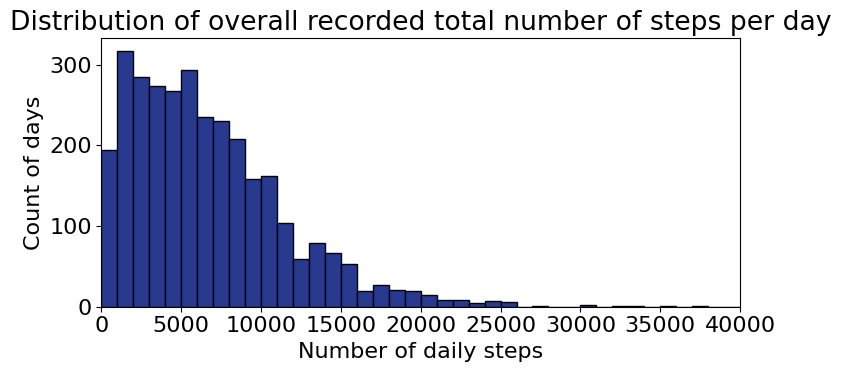

In [74]:
plt.figure(figsize=(8,4))

bins = np.arange(0, 41000, 1000)

plt.hist(steps, bins=bins, color="#283a8f", edgecolor="black")

plt.xlabel("Number of daily steps")
plt.ylabel("Count of days")
plt.title("Distribution of overall recorded total number of steps per day")

plt.xlim(0, 40000)
plt.tight_layout()
plt.show()


## RHR analysis(pre/post ovulation)

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df_rhr = df_select.copy()

df_rhr["resting_heart_rate"] = pd.to_numeric(df_rhr["resting_heart_rate"], errors="coerce")
df_rhr["cycle_length"] = pd.to_numeric(df_rhr["cycle_length"], errors="coerce")

if "fitbit_valid" in df_rhr.columns:
    df_rhr = df_rhr[df_rhr["fitbit_valid"] == 1]

df_rhr = df_rhr[(df_rhr["cycle_length"] >= 21) & (df_rhr["cycle_length"] <= 35)]

df_rhr = df_rhr[df_rhr["day_in_cycle"] <= df_rhr["cycle_length"]]

df_rhr["ovulation_day"] = df_rhr["cycle_length"] - 14

df_rhr["ovu_phase"] = np.where(
    df_rhr["day_in_cycle"] <= df_rhr["ovulation_day"],
    "Pre Ovulation",
    "Post Ovulation"
)


In [76]:
# Reference Paper Rules
df_rhr["ovulation_day"] = df_rhr["cycle_length"] - 14

df_rhr["ovu_phase"] = np.where(
    df_rhr["day_in_cycle"] <= df_rhr["ovulation_day"],
    "Pre Ovulation",
    "Post Ovulation"
)


/var/tmp/ipykernel_5634/1155171910.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


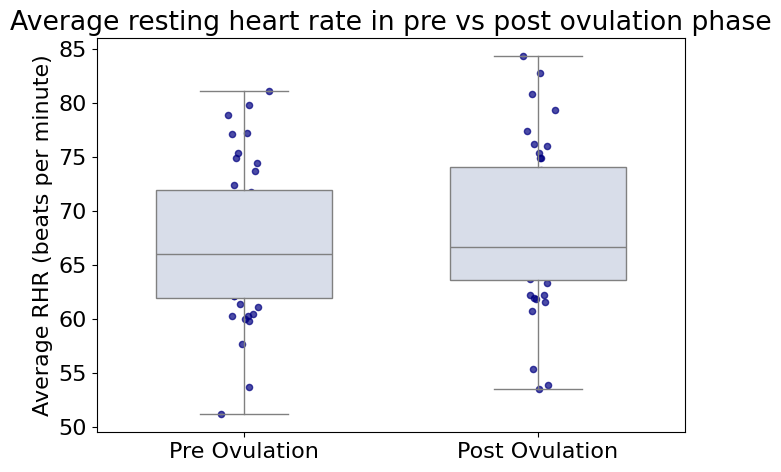

In [77]:
phase_rhr = (
    df_rhr.groupby(["id", "ovu_phase"])["resting_heart_rate"]
          .mean()
          .reset_index()
)

pre_vals  = phase_rhr.loc[phase_rhr["ovu_phase"] == "Pre Ovulation",
                          "resting_heart_rate"].values
post_vals = phase_rhr.loc[phase_rhr["ovu_phase"] == "Post Ovulation",
                          "resting_heart_rate"].values

plt.figure(figsize=(7,5))
ax = plt.gca()

data_to_plot = [pre_vals, post_vals]

box = ax.boxplot(
    data_to_plot,
    labels=["Pre Ovulation", "Post Ovulation"],
    patch_artist=True,
    widths=0.6
)

for patch in box["boxes"]:
    patch.set_facecolor("#d8dde9")
    patch.set_edgecolor("gray")
for whisker in box["whiskers"]:
    whisker.set_color("gray")
for cap in box["caps"]:
    cap.set_color("gray")
for median in box["medians"]:
    median.set_color("gray")

rng = np.random.default_rng(42)
x_pre  = np.ones_like(pre_vals)  + rng.normal(scale=0.04, size=len(pre_vals))
x_post = np.ones_like(post_vals) * 2 + rng.normal(scale=0.04, size=len(post_vals))

ax.scatter(x_pre,  pre_vals,  color="navy", alpha=0.7, s=20)
ax.scatter(x_post, post_vals, color="navy", alpha=0.7, s=20)

ax.set_title("Average resting heart rate in pre vs post ovulation phase")
ax.set_ylabel("Average RHR (beats per minute)")
plt.tight_layout()
plt.show()


/var/tmp/ipykernel_5634/2942670797.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=["Pre Ovulation", "Post Ovulation"],


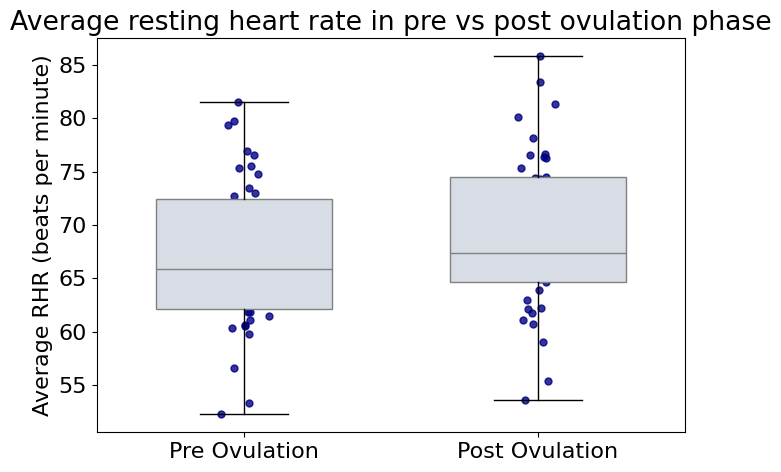

In [78]:
## Using phases in McPhases
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_plot = df_select.copy()
df_plot["resting_heart_rate"] = pd.to_numeric(df_plot["resting_heart_rate"], errors="coerce")

phase_map = {
    "Menstrual": "Pre Ovulation",
    "Follicular": "Pre Ovulation",
    "Fertility": "Pre Ovulation",
    "Luteal": "Post Ovulation"
}
df_plot["ovu_phase"] = df_plot["phase"].map(phase_map)

avg_rhr = (
    df_plot.groupby(["id", "ovu_phase"])["resting_heart_rate"]
           .mean()
           .reset_index()
)

wide = avg_rhr.pivot(index="id", columns="ovu_phase", values="resting_heart_rate").dropna()
pre = wide["Pre Ovulation"].values
post = wide["Post Ovulation"].values

plt.figure(figsize=(7,5))
ax = plt.gca()
data = [pre, post]

box = ax.boxplot(data, labels=["Pre Ovulation", "Post Ovulation"],
                 patch_artist=True, widths=0.6)

for patch in box["boxes"]:
    patch.set_facecolor("#d7dce5")
    patch.set_edgecolor("gray")
for median in box["medians"]:
    median.set_color("gray")

rng = np.random.default_rng(42)
ax.scatter(1 + rng.normal(0,0.04,len(pre)), pre, color="navy", alpha=0.8, s=25)
ax.scatter(2 + rng.normal(0,0.04,len(post)), post, color="navy", alpha=0.8, s=25)

ax.set_title("Average resting heart rate in pre vs post ovulation phase")
ax.set_ylabel("Average RHR (beats per minute)")
plt.tight_layout()
plt.show()

## Run the explicit mixed-effects models (conceptual replication)

In [79]:
for i in df_select.columns:
    print(i)

id
day_in_study
phase
resting_heart_rate
steps
calories
minutesasleep
flow_volume
headaches
cramps
sorebreasts
fatigue
moodswing
indigestion
bloating
age
height2022
weight2022
nightly_temperature
BMI
week_in_study
fitbit_valid
questionnaire_completed
cycle
cycle_length
complete_day
day_in_cycle


In [80]:
import statsmodels.formula.api as smf

df_clean = df_select[["resting_heart_rate", "phase", "id"]].dropna().reset_index(drop=True)

# Model 1: Phase only (with random intercept per subject)
model1 = smf.mixedlm("resting_heart_rate ~ C(phase)", 
                      data=df_clean, 
                      groups=df_clean["id"])
result1 = model1.fit()
print(result1.summary())

              Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: resting_heart_rate
No. Observations:  2872    Method:             REML              
No. Groups:        42      Scale:              7.0665            
Min. group size:   21      Log-Likelihood:     -7012.0235        
Max. group size:   90      Converged:          Yes               
Mean group size:   68.4                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              67.164    1.090 61.612 0.000 65.028 69.301
C(phase)[T.Follicular] -0.660    0.145 -4.564 0.000 -0.943 -0.376
C(phase)[T.Luteal]      2.067    0.140 14.753 0.000  1.793  2.342
C(phase)[T.Menstrual]   0.736    0.152  4.843 0.000  0.438  1.033
Group Var              49.427    4.145                           



In [81]:
# Model 2: Phase + age
df_clean2 = df_select[["resting_heart_rate", "phase", "id", "age"]].dropna().reset_index(drop=True)

model2 = smf.mixedlm("resting_heart_rate ~ C(phase) + age", 
                      data=df_clean2, 
                      groups=df_clean2["id"])
result2 = model2.fit()
print(result2.summary())

              Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: resting_heart_rate
No. Observations:  2872    Method:             REML              
No. Groups:        42      Scale:              7.0665            
Min. group size:   21      Log-Likelihood:     -7011.9800        
Max. group size:   90      Converged:          Yes               
Mean group size:   68.4                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              65.222    8.594  7.589 0.000 48.378 82.067
C(phase)[T.Follicular] -0.660    0.145 -4.564 0.000 -0.943 -0.376
C(phase)[T.Luteal]      2.067    0.140 14.753 0.000  1.793  2.342
C(phase)[T.Menstrual]   0.736    0.152  4.843 0.000  0.438  1.033
age                     0.093    0.408  0.228 0.820 -0.707  0.893
Group Var              5

In [82]:
# Model 3: Phase + age + BMI
df_clean3 = df_select[["resting_heart_rate", "phase", "id", "age", "BMI"]].dropna().reset_index(drop=True)

model3 = smf.mixedlm("resting_heart_rate ~ C(phase) + age + BMI", 
                      data=df_clean3, 
                      groups=df_clean3["id"])
result3 = model3.fit()
print(result3.summary())

              Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: resting_heart_rate
No. Observations:  1417    Method:             REML              
No. Groups:        19      Scale:              6.9840            
Min. group size:   49      Log-Likelihood:     -3443.2185        
Max. group size:   90      Converged:          Yes               
Mean group size:   74.6                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              52.410   12.037  4.354 0.000 28.818 76.003
C(phase)[T.Follicular] -0.142    0.204 -0.698 0.485 -0.541  0.257
C(phase)[T.Luteal]      2.655    0.195 13.615 0.000  2.273  3.037
C(phase)[T.Menstrual]   1.373    0.215  6.386 0.000  0.952  1.795
age                     0.813    0.566  1.437 0.151 -0.296  1.923
BMI                    -

In [83]:
for i in df_select.columns:
    print(i)

id
day_in_study
phase
resting_heart_rate
steps
calories
minutesasleep
flow_volume
headaches
cramps
sorebreasts
fatigue
moodswing
indigestion
bloating
age
height2022
weight2022
nightly_temperature
BMI
week_in_study
fitbit_valid
questionnaire_completed
cycle
cycle_length
complete_day
day_in_cycle


In [84]:
import statsmodels.formula.api as smf

df_clean = df_select[["resting_heart_rate", "phase", "id"]].dropna().reset_index(drop=True)

# Model 1: Phase only (with random intercept per subject)
model1 = smf.mixedlm("resting_heart_rate ~ C(phase)", 
                      data=df_clean, 
                      groups=df_clean["id"])
result1 = model1.fit()
print(result1.summary())


              Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: resting_heart_rate
No. Observations:  2872    Method:             REML              
No. Groups:        42      Scale:              7.0665            
Min. group size:   21      Log-Likelihood:     -7012.0235        
Max. group size:   90      Converged:          Yes               
Mean group size:   68.4                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              67.164    1.090 61.612 0.000 65.028 69.301
C(phase)[T.Follicular] -0.660    0.145 -4.564 0.000 -0.943 -0.376
C(phase)[T.Luteal]      2.067    0.140 14.753 0.000  1.793  2.342
C(phase)[T.Menstrual]   0.736    0.152  4.843 0.000  0.438  1.033
Group Var              49.427    4.145                           



In [85]:
# Model 2: Phase + age
df_clean2 = df_select[["resting_heart_rate", "phase", "id", "age"]].dropna().reset_index(drop=True)

model2 = smf.mixedlm("resting_heart_rate ~ C(phase) + age", 
                      data=df_clean2, 
                      groups=df_clean2["id"])
result2 = model2.fit()
print(result2.summary())


              Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: resting_heart_rate
No. Observations:  2872    Method:             REML              
No. Groups:        42      Scale:              7.0665            
Min. group size:   21      Log-Likelihood:     -7011.9800        
Max. group size:   90      Converged:          Yes               
Mean group size:   68.4                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              65.222    8.594  7.589 0.000 48.378 82.067
C(phase)[T.Follicular] -0.660    0.145 -4.564 0.000 -0.943 -0.376
C(phase)[T.Luteal]      2.067    0.140 14.753 0.000  1.793  2.342
C(phase)[T.Menstrual]   0.736    0.152  4.843 0.000  0.438  1.033
age                     0.093    0.408  0.228 0.820 -0.707  0.893
Group Var              5

In [86]:
# Model 3: Phase + age + BMI
df_clean3 = df_select[["resting_heart_rate", "phase", "id", "age", "BMI"]].dropna().reset_index(drop=True)

model3 = smf.mixedlm("resting_heart_rate ~ C(phase) + age + BMI", 
                      data=df_clean3, 
                      groups=df_clean3["id"])
result3 = model3.fit()
print(result3.summary())

              Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: resting_heart_rate
No. Observations:  1417    Method:             REML              
No. Groups:        19      Scale:              6.9840            
Min. group size:   49      Log-Likelihood:     -3443.2185        
Max. group size:   90      Converged:          Yes               
Mean group size:   74.6                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              52.410   12.037  4.354 0.000 28.818 76.003
C(phase)[T.Follicular] -0.142    0.204 -0.698 0.485 -0.541  0.257
C(phase)[T.Luteal]      2.655    0.195 13.615 0.000  2.273  3.037
C(phase)[T.Menstrual]   1.373    0.215  6.386 0.000  0.952  1.795
age                     0.813    0.566  1.437 0.151 -0.296  1.923
BMI                    -

In [87]:
df_clean4 = df_select[["steps", "phase", "id", "age", "BMI"]].dropna().reset_index(drop=True)
model_steps = smf.mixedlm("steps ~ C(phase) + age + BMI", 
                          data=df_clean4, 
                          groups=df_clean4["id"])
result_steps = model_steps.fit()
print(result_steps.summary())

                   Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      steps        
No. Observations:       1521         Method:                  REML         
No. Groups:             19           Scale:                   16038334.7892
Min. group size:        55           Log-Likelihood:          -14768.2413  
Max. group size:        90           Converged:               Yes          
Mean group size:        80.1                                               
---------------------------------------------------------------------------
                          Coef.    Std.Err.   z    P>|z|  [0.025    0.975] 
---------------------------------------------------------------------------
Intercept                 9709.780 5425.584  1.790 0.074 -924.169 20343.729
C(phase)[T.Follicular]     399.832  298.127  1.341 0.180 -184.485   984.149
C(phase)[T.Luteal]         411.391  286.075  1.438 0.150 -149.305   972.087
C(phase)[T.Menstrual]      358.

In [88]:
df_clean5 = df_select[["minutesasleep", "phase", "id", "age", "BMI"]].dropna().reset_index(drop=True)
model_sleep = smf.mixedlm("minutesasleep ~ C(phase) + age + BMI", 
                          data=df_clean5, 
                          groups=df_clean5["id"])
result_sleep = model_sleep.fit()
print(result_sleep.summary())

                Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    minutesasleep
No. Observations:     1417       Method:                REML         
No. Groups:           19         Scale:                 16450.9827   
Min. group size:      49         Log-Likelihood:        -8894.3874   
Max. group size:      90         Converged:             Yes          
Mean group size:      74.6                                           
---------------------------------------------------------------------
                        Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------
Intercept               451.201  111.236  4.056 0.000 233.183 669.220
C(phase)[T.Follicular]    4.956    9.871  0.502 0.616 -14.391  24.304
C(phase)[T.Luteal]        3.394    9.457  0.359 0.720 -15.141  21.930
C(phase)[T.Menstrual]    10.574   10.436  1.013 0.311  -9.879  31.027
age                      -3.051    5

In [175]:
df_clean6 = df_select[["nightly_temperature", "phase", "id", "age", "BMI"]].dropna().reset_index(drop=True)
model_temp = smf.mixedlm("nightly_temperature ~ C(phase) + age + BMI", 
                          data=df_clean6, 
                          groups=df_clean6["id"])
result_temp = model_temp.fit()
result_temp.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
=================================================================
Model:            MixedLM Dependent Variable: nightly_temperature
No. Observations: 1387    Method:             REML               
No. Groups:       19      Scale:              0.3599             
Min. group size:  49      Log-Likelihood:     -1308.3063         
Max. group size:  88      Converged:          Yes                
Mean group size:  73.0                                           
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              33.333    1.058 31.518 0.000 31.261 35.406
C(phase)[T.Follicular] -0.029    0.047 -0.629 0.530 -0.121  0.062
C(phase)[T.Luteal]      0.248    0.045  5.551 0.000  0.161  0.336
C(phase)[T.Menstrual]   0.147    0.049  2.977 0.003  0.050  0.243
age                     0.065    0.050  1.317 0.188 -0.032  0.163
BMI                    -0.036    0.032 -1.120 0.263 -0.099  0.027
Group Var               0.312    0.188                           
=================================================================

"""

Index(['id', 'day_in_study', 'phase', 'resting_heart_rate', 'steps',
       'calories', 'minutesasleep', 'flow_volume', 'headaches', 'cramps',
       'sorebreasts', 'fatigue', 'moodswing', 'indigestion', 'bloating', 'age',
       'height2022', 'weight2022', 'BMI', 'week_in_study', 'fitbit_valid',
       'questionnaire_completed', 'cycle', 'cycle_length', 'complete_day',
       'day_in_cycle', 'PMS_score', 'PMS_group'],
      dtype='object')